# Cat Image Generator (DCGAN)

A Deep Convolutional GAN built with PyTorch that generates 64×64 cat face images from random noise.

## Overview

| | |
|---|---|
| **Task** | Image generation — cat faces 64×64 RGB |
| **Generator** | ConvTranspose2d (100D latent → 64×64×3 image) |
| **Discriminator** | Conv2d (64×64×3 image → real/fake probability) |
| **Loss** | BCELoss |
| **Optimizer** | Adam (lr=2e-4, betas=(0.5, 0.999)) |
| **Framework** | PyTorch |

## How to run
1. Set runtime to **GPU** : Runtime → Change runtime type → T4 GPU
2. Click **Runtime → Run all**

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alicelmre2705/deep-learning-projects/blob/main/cat_image_generator.ipynb)

## 1. Setup

In [ ]:
!pip install -q torch torchvision numpy matplotlib gdown

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/deep-learning-results'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Results will be saved to: {SAVE_DIR}')


Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/deep-learning-results


In [ ]:
import torch
from torch import nn
from torchvision.io import read_image
import matplotlib.pyplot as plt
import numpy as np
import os
import gdown
import zipfile

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [ ]:
BATCH_SIZE = 64
LATENT_DIM = 100
EPOCHS     = 20
LR         = 2e-4
BETAS      = (0.5, 0.999)

## 2. Dataset Download

Cat face images (64×64 RGB) downloaded from Google Drive.

In [ ]:
DATASET_DIR = './dataset'

if not os.path.exists(DATASET_DIR) or len(os.listdir(DATASET_DIR)) == 0:
    import tarfile
    url = 'https://drive.google.com/uc?id=1F9I7iDmQ_I9Qsrav1UXlD4OiIBVSU5sl'
    output = 'dataset.tgz'
    print('Downloading cat dataset...')
    gdown.download(url, output, quiet=False)
    with tarfile.open(output, 'r:*') as tf:
        tf.extractall('./')
    print(f'Done. {len(os.listdir(DATASET_DIR))} images found.')
else:
    print(f'Dataset already present ({len(os.listdir(DATASET_DIR))} files)')

Done. 15747 images found.


In [ ]:
x_train = []
batch   = []

for filename in sorted(os.listdir(DATASET_DIR)):
    try:
        image = read_image(os.path.join(DATASET_DIR, filename)).float() / 127.5 - 1.0
        if image.shape == torch.Size([3, 64, 64]):
            batch.append(image)
            if len(batch) == BATCH_SIZE:
                x_train.append(torch.stack(batch))
                batch = []
    except Exception:
        continue

x_train = torch.stack(x_train)
print(f'Loaded {len(x_train)} batches of {BATCH_SIZE} images ({len(x_train) * BATCH_SIZE} total)')

Loaded 246 batches of 64 images (15744 total)


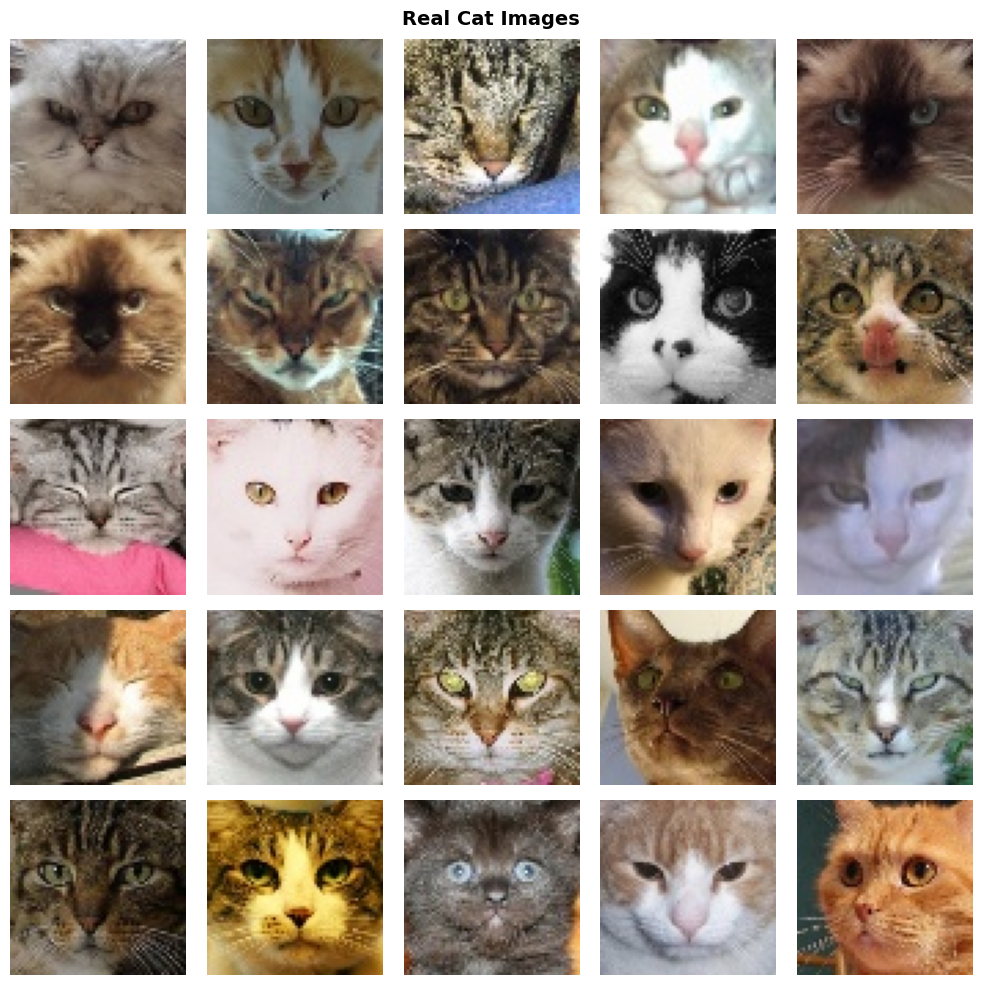

In [ ]:
def show_grid(images, title='', nrow=5):
    fig, axes = plt.subplots(nrow, nrow, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow((images[i].permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1))
        ax.axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_grid(x_train[0], title='Real Cat Images')

## 3. Model Definitions

Following DCGAN guidelines:
- **BatchNorm** in both networks (except generator output and discriminator input)
- **ReLU** for generator, **LeakyReLU(0.2)** for discriminator
- **Tanh** output for generator (images in [-1, 1])
- Strided convolutions instead of pooling

### Discriminator

In [ ]:
discriminator = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),       # 64→32
    nn.LeakyReLU(0.2),

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),     # 32→16
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2),

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),    # 16→8
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2),

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),    # 8→4
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2),

    nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),      # 4→1
    nn.Flatten(),
    nn.Sigmoid(),
).to(device)

print(f'Discriminator  |  {sum(p.numel() for p in discriminator.parameters()):,} parameters')

Discriminator  |  2,766,529 parameters


### Generator

In [ ]:
generator = nn.Sequential(
    nn.ConvTranspose2d(LATENT_DIM, 512, kernel_size=4, stride=1, padding=0),  # 1→4
    nn.BatchNorm2d(512),
    nn.ReLU(),

    nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),          # 4→8
    nn.BatchNorm2d(256),
    nn.ReLU(),

    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),          # 8→16
    nn.BatchNorm2d(128),
    nn.ReLU(),

    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),           # 16→32
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),             # 32→64
    nn.Tanh(),
).to(device)

print(f'Generator      |  {sum(p.numel() for p in generator.parameters()):,} parameters')

Generator      |  3,577,667 parameters


## 4. Training

Each step:
1. **Discriminator** learns to tell real from fake
2. **Generator** learns to fool the discriminator

In [ ]:
def train_step(real_images, generator, discriminator, loss_fn, g_opt, d_opt):
    batch_size  = real_images.size(0)
    real_labels = torch.ones(batch_size, 1, device=device)
    fake_labels = torch.zeros(batch_size, 1, device=device)

    noise       = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
    fake_images = generator(noise)

    # Train discriminator
    discriminator.zero_grad()
    d_loss_real = loss_fn(discriminator(real_images), real_labels)
    d_loss_fake = loss_fn(discriminator(fake_images.detach()), fake_labels)
    d_loss = d_loss_real + d_loss_fake
    d_loss.backward()
    d_opt.step()

    # Train generator
    generator.zero_grad()
    g_loss = loss_fn(discriminator(fake_images), real_labels)
    g_loss.backward()
    g_opt.step()

    return g_loss.item(), d_loss.item()

In [ ]:
loss_fn = nn.BCELoss()
g_opt   = torch.optim.Adam(generator.parameters(),     lr=LR, betas=BETAS)
d_opt   = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=BETAS)

fixed_noise = torch.randn(25, LATENT_DIM, 1, 1, device=device)
g_losses, d_losses = [], []

for epoch in range(EPOCHS):
    epoch_g, epoch_d, n = 0.0, 0.0, 0

    idx = torch.randperm(len(x_train))
    for batch in x_train[idx]:
        batch = batch.to(device)
        gl, dl = train_step(batch, generator, discriminator, loss_fn, g_opt, d_opt)
        epoch_g += gl
        epoch_d += dl
        n += 1

    g_losses.append(epoch_g / n)
    d_losses.append(epoch_d / n)
    print(f'Epoch {epoch+1:2d}/{EPOCHS}  |  G Loss: {epoch_g/n:.4f}  |  D Loss: {epoch_d/n:.4f}')

    if epoch == 0 or (epoch + 1) % 10 == 0:
        with torch.no_grad():
            show_grid(generator(fixed_noise).cpu(), title=f'Generated — Epoch {epoch+1}')

print('\nTraining complete.')

Epoch  1/20  |  G Loss: 6.5604  |  D Loss: 0.6552
Epoch  2/20  |  G Loss: 3.4457  |  D Loss: 0.8036
Epoch  3/20  |  G Loss: 3.9126  |  D Loss: 0.8075
Epoch  4/20  |  G Loss: 4.4932  |  D Loss: 0.7176
Epoch  5/20  |  G Loss: 4.5188  |  D Loss: 0.6623
Epoch  6/20  |  G Loss: 4.6773  |  D Loss: 0.6518
Epoch  7/20  |  G Loss: 4.5354  |  D Loss: 0.6044
Epoch  8/20  |  G Loss: 4.5571  |  D Loss: 0.5800
Epoch  9/20  |  G Loss: 4.8864  |  D Loss: 0.5037
Epoch 10/20  |  G Loss: 4.8027  |  D Loss: 0.4983
Epoch 11/20  |  G Loss: 4.6742  |  D Loss: 0.5119
Epoch 12/20  |  G Loss: 4.9128  |  D Loss: 0.4457
Epoch 13/20  |  G Loss: 5.0682  |  D Loss: 0.4121
Epoch 14/20  |  G Loss: 5.1082  |  D Loss: 0.3589
Epoch 15/20  |  G Loss: 5.4901  |  D Loss: 0.3270
Epoch 16/20  |  G Loss: 5.6406  |  D Loss: 0.3219
Epoch 17/20  |  G Loss: 5.8202  |  D Loss: 0.2444
Epoch 18/20  |  G Loss: 6.2585  |  D Loss: 0.2011
Epoch 19/20  |  G Loss: 6.1228  |  D Loss: 0.3261
Epoch 20/20  |  G Loss: 6.0451  |  D Loss: 0.2897


## 5. Training Curves

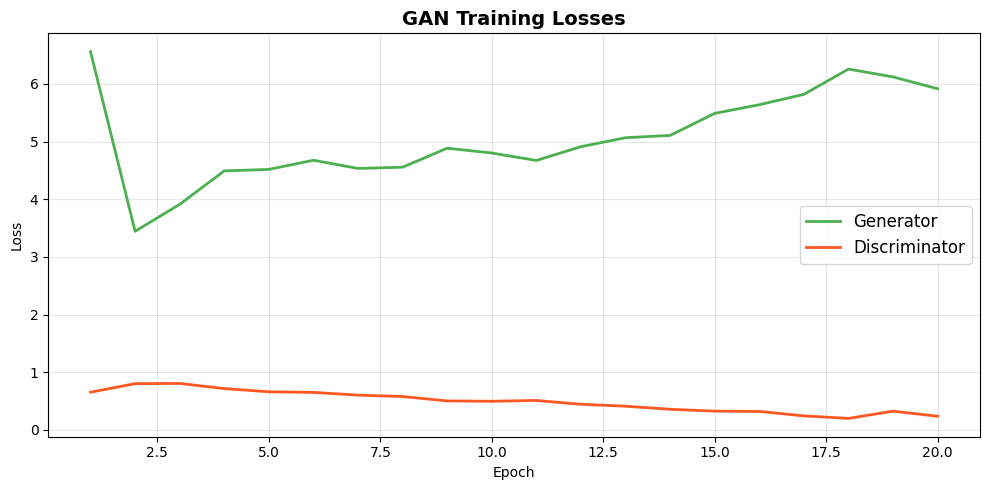

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(g_losses)+1), g_losses, label='Generator',     color='#4CAF50', linewidth=2)
ax.plot(range(1, len(d_losses)+1), d_losses, label='Discriminator', color='#FF5722', linewidth=2)
ax.set_title('GAN Training Losses', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Save Models

In [ ]:
import shutil, os, json

# Save model weights to Drive
torch.save(generator.state_dict(),     'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')
shutil.copy('generator.pth',     f'{SAVE_DIR}/generator.pth')
shutil.copy('discriminator.pth', f'{SAVE_DIR}/discriminator.pth')
print(f'Saved  →  {SAVE_DIR}/generator.pth')
print(f'Saved  →  {SAVE_DIR}/discriminator.pth')

# Save this notebook (with outputs) to Drive
from google.colab import _message
try:
    nb_data = _message.blocking_request('get_ipynb', request={}, timeout_sec=60)
    dest = '/content/drive/MyDrive/Colab Notebooks/cat_image_generator.ipynb'
    with open(dest, 'w') as f:
        json.dump(nb_data['ipynb'], f, indent=1, ensure_ascii=False)
    print(f'Notebook saved  →  Colab Notebooks/cat_image_generator.ipynb')
except Exception as e:
    print(f'Auto-save failed: {e}')
    print('→ File → Save a copy in Drive')


Saved  →  /content/drive/MyDrive/deep-learning-results/generator.pth
Saved  →  /content/drive/MyDrive/deep-learning-results/discriminator.pth
Notebook saved  →  Colab Notebooks/cat_image_generator.ipynb


## 7. Results

Final images generated after 20 epochs of training:

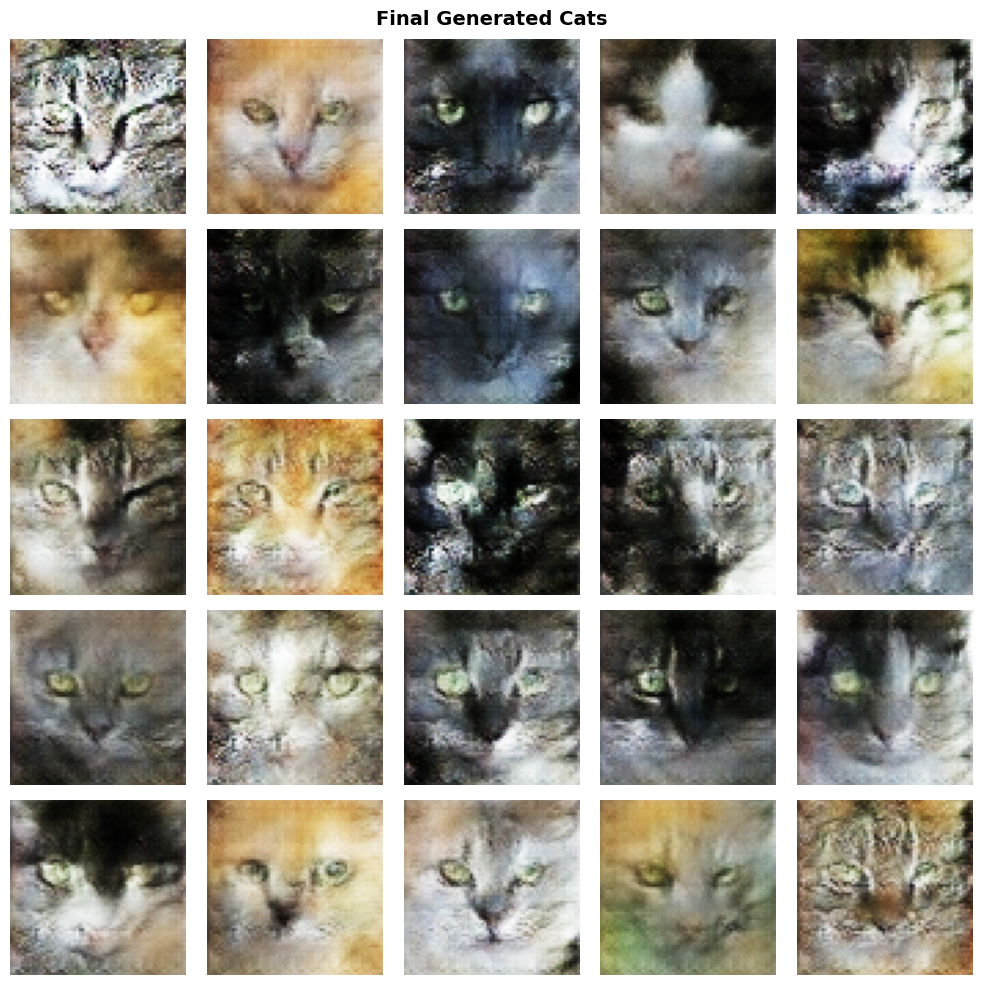

In [ ]:
generator.eval()
with torch.no_grad():
    noise = torch.randn(25, LATENT_DIM, 1, 1, device=device)
    show_grid(generator(noise).cpu(), title='Generated Cats — After 20 Epochs')

## 8. Load and Inference

To generate new images from saved weights without retraining:

In [ ]:
# Uncomment to load and generate:
#
# generator.load_state_dict(torch.load('generator.pth', map_location=device))
# generator.eval()
# with torch.no_grad():
#     noise = torch.randn(25, LATENT_DIM, 1, 1, device=device)
#     show_grid(generator(noise).cpu(), title='Inference from Saved Model')

## 9. Conclusion

**Results**: After 20 epochs the generator produces recognizable cat-like faces with eyes, ears and fur patterns.

**Key takeaways**:
- GANs learn through an adversarial game — generator and discriminator improve in tandem.
- DCGAN guidelines (BatchNorm, LeakyReLU, strided convolutions) are critical for stable training.
- The D Loss decreasing while G Loss increases is normal — the discriminator gets better at detecting fakes.

**Possible improvements**:
- Wasserstein loss (WGAN-GP) for more stable training
- More epochs and a larger dataset for sharper results
- FID score for quantitative evaluation